# Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Load Dataset

In [16]:
df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Dataset Overview

In [20]:
print("Shape :", df.shape)

df.columns

df.info()

df.describe()

df.describe(include= [ "object" ,  "string" ])

Shape : (119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal  

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


# Data Cleaning

In [22]:
missing = df.isnull().sum()

missing[missing>0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [23]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent>0]

children     0.003350
country      0.408744
agent       13.686238
company     94.306893
dtype: float64

# Duplicate Records

In [24]:
print("Duplicate Records :",df.duplicated().sum())

Duplicate Records : 31994


In [25]:
df = df.drop_duplicates()

print(df.shape)

(87396, 32)


# Exploratory Data Analysis

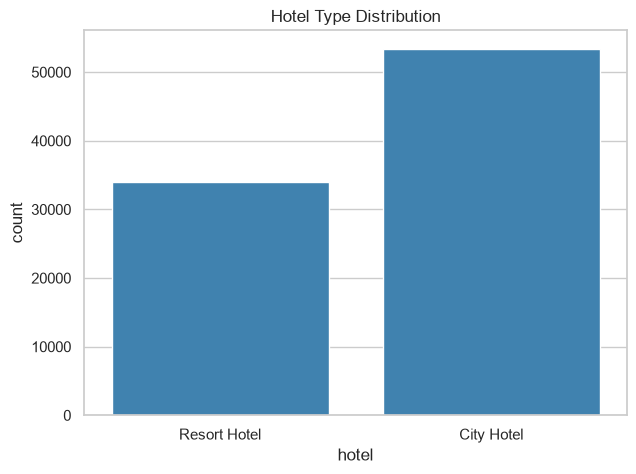

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="hotel",
    color="#2E86C1"
)

plt.title("Hotel Type Distribution")
plt.show()

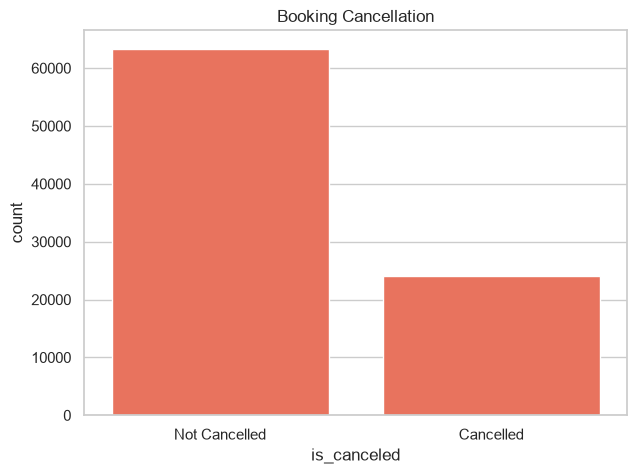

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="is_canceled",
    color="tomato"
)

plt.xticks(
    [0,1],
    ["Not Cancelled","Cancelled"]
)

plt.title("Booking Cancellation")
plt.show()

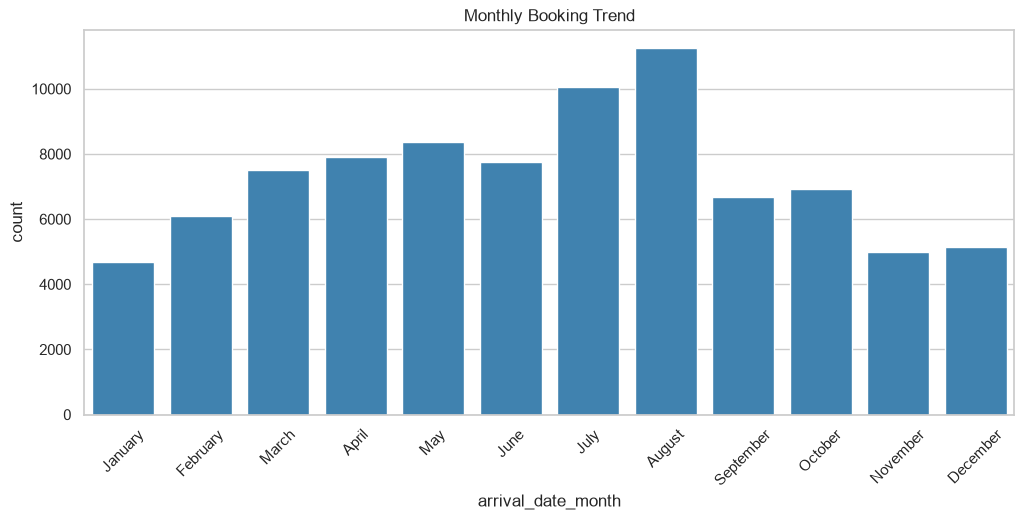

In [28]:
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="arrival_date_month",
    order=months,
    color="#2E86C1"
)

plt.xticks(rotation=45)

plt.title("Monthly Booking Trend")

plt.show()

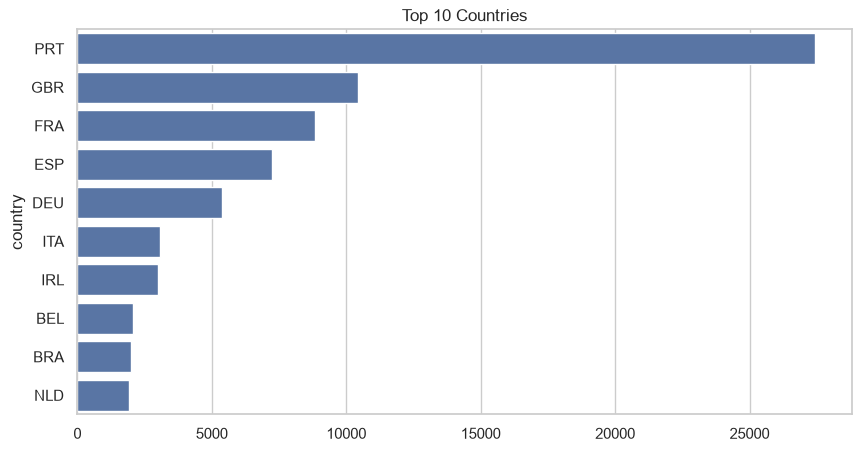

In [29]:
top = df.country.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top 10 Countries")

plt.show()

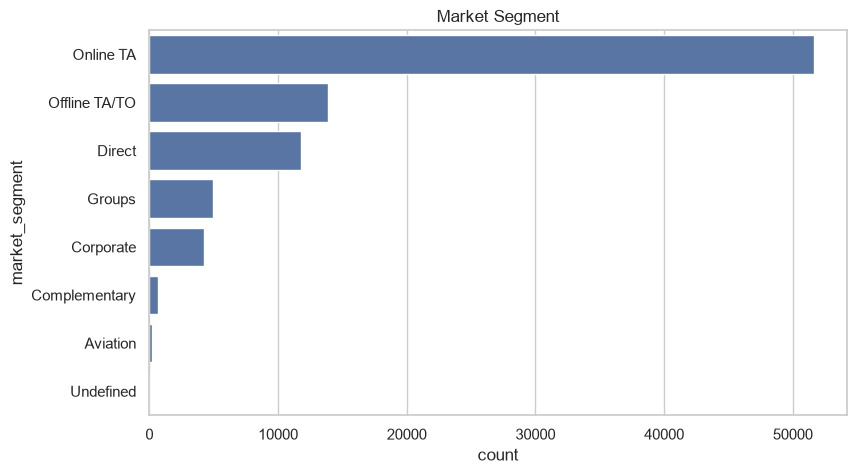

In [30]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="market_segment",
    order=df.market_segment.value_counts().index
)

plt.title("Market Segment")

plt.show()

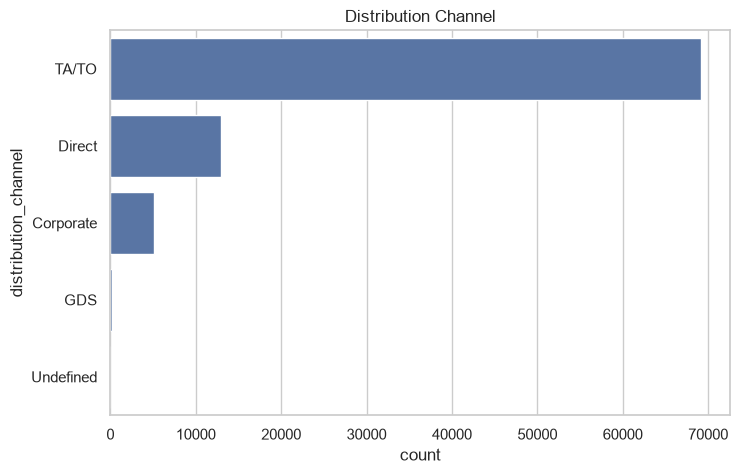

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="distribution_channel",
    order=df.distribution_channel.value_counts().index
)

plt.title("Distribution Channel")

plt.show()

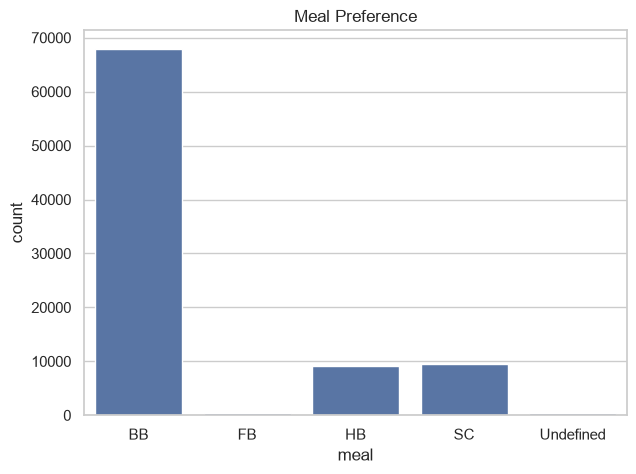

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="meal"
)

plt.title("Meal Preference")

plt.show()

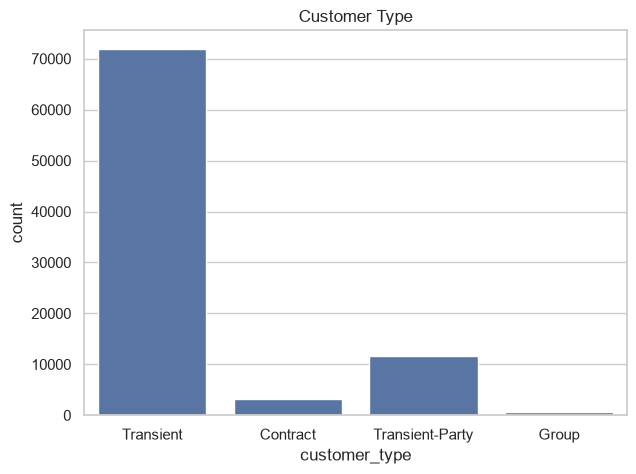

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="customer_type"
)

plt.title("Customer Type")

plt.show()

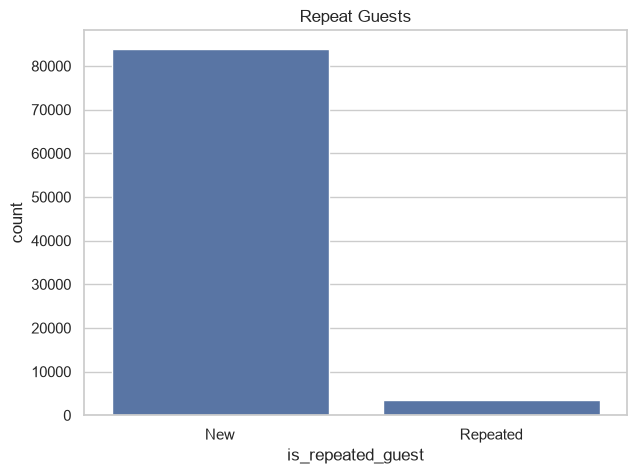

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="is_repeated_guest"
)

plt.xticks(
    [0,1],
    ["New","Repeated"]
)

plt.title("Repeat Guests")

plt.show()

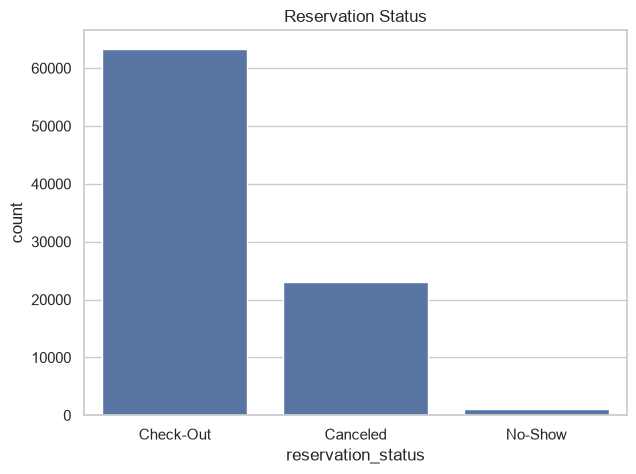

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="reservation_status"
)

plt.title("Reservation Status")

plt.show()

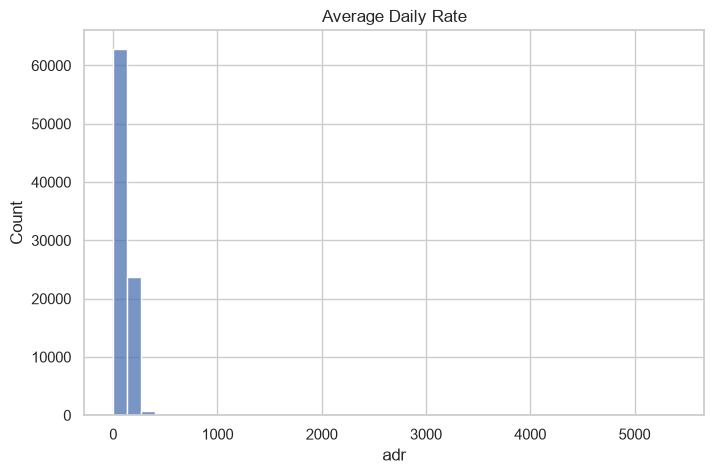

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["adr"],
    bins=40
)

plt.title("Average Daily Rate")

plt.show()

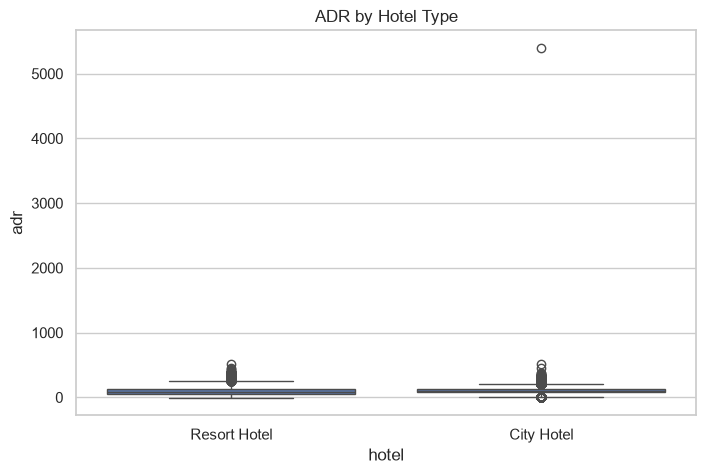

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.title("ADR by Hotel Type")

plt.show()

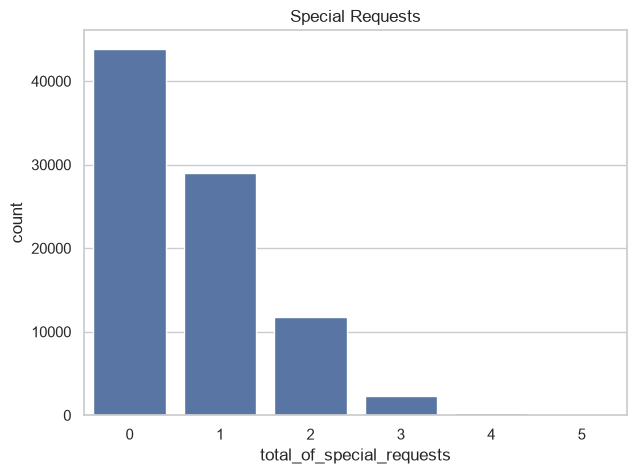

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="total_of_special_requests"
)

plt.title("Special Requests")

plt.show()

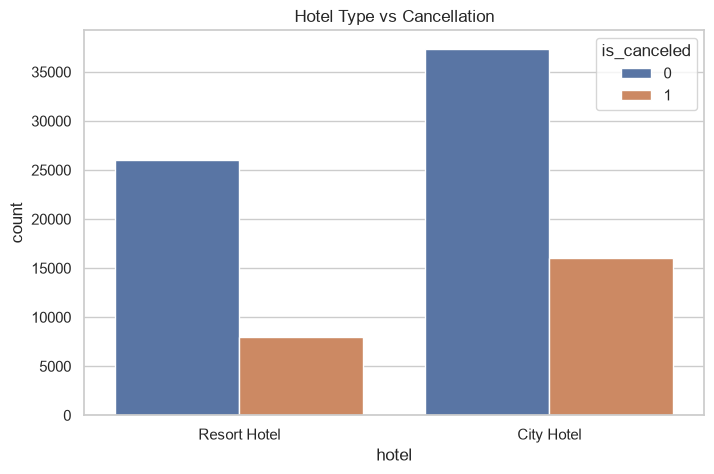

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Hotel Type vs Cancellation")

plt.show()

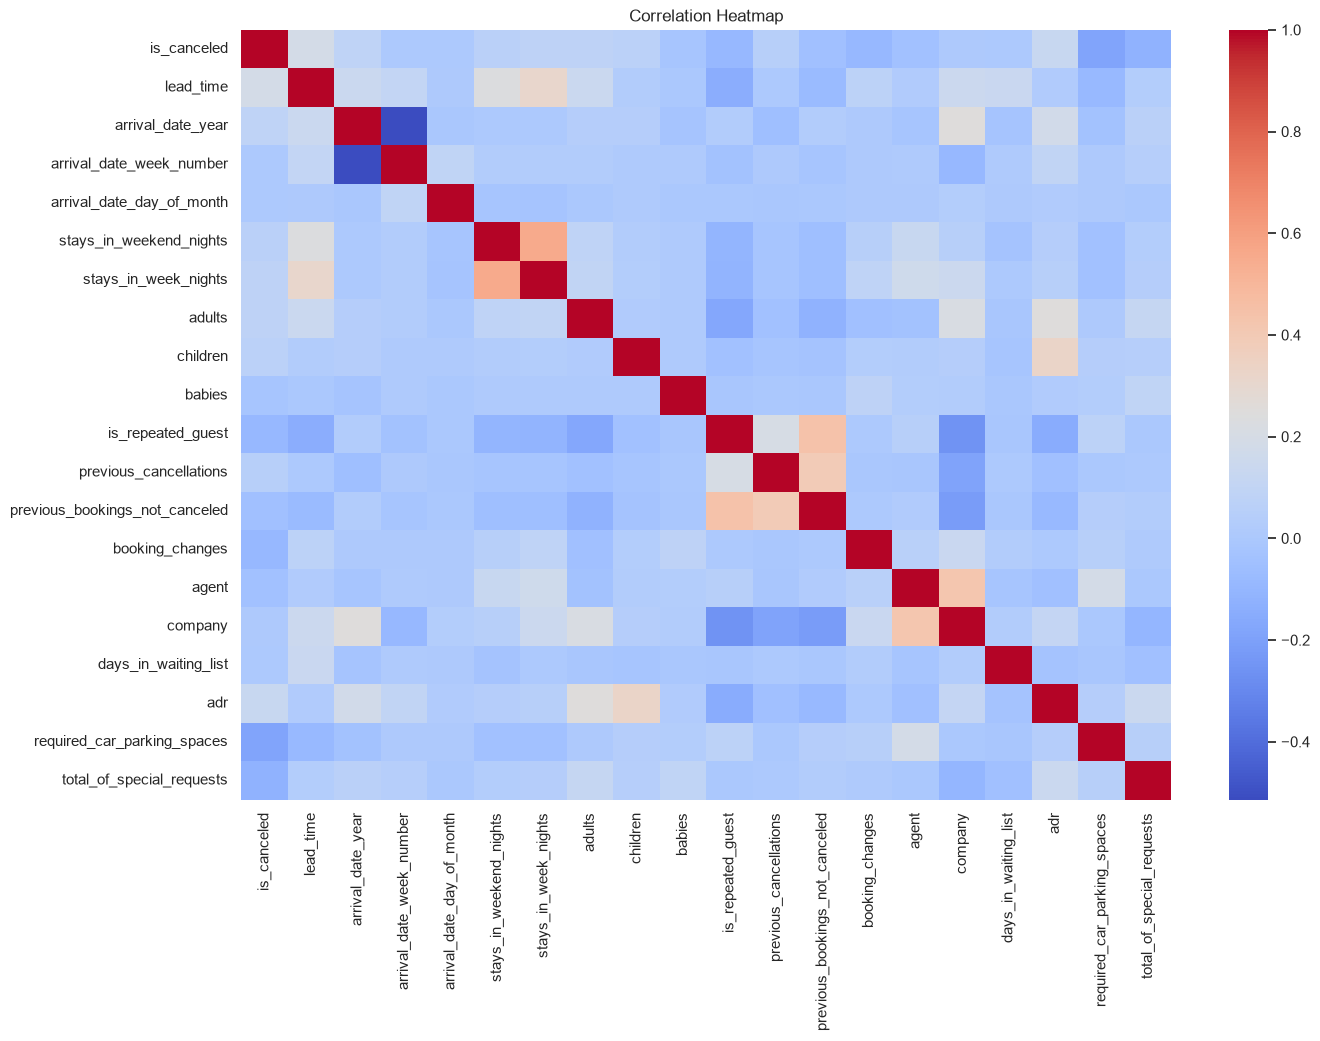

In [41]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Findings

## Key Findings

• The dataset originally contained 119,390 records.

• After removing 31,994 duplicate records, 87,396 records remained.

• City Hotels account for approximately 61% of all bookings.

• Around 37% of bookings were cancelled.

• The average lead time is approximately 104 days.

• The average ADR is $101.83, with noticeable outliers.

• Repeat guests represent only about 3.2% of customers.

• Most bookings originate from online travel agencies and transient customers.

# Business Recommendations

## Business Recommendations

• Increase customer loyalty through reward programs.

• Reduce cancellations using reminder emails and flexible cancellation policies.

• Improve data quality by handling missing values and validating ADR entries.

• Implement dynamic pricing based on booking demand and seasonality.

• Enhance marketing campaigns by targeting high-value customer segments.